

## 과제 목적
이번 과제는 수업에서 다룬 **Grain, Cardinality, JOIN, CTE, Window Function, 파생변수**를 실제 Olist 데이터에 직접 적용하는 것을 목표로 합니다. 단순히 SQL이 실행되는지 확인하는 것이 아니라, **결과가 분석적으로 올바른지 직접 검증하고 그 의미를 해석**해야 합니다. 생성형 AI를 사용할 수 있지만, AI가 제안한 쿼리나 해석을 그대로 제출하는 것이 아니라 **본인의 로컬 DB에서 실행 결과를 확인하고, 지표 정의와 JOIN 구조가 타당한지 판단**해야 합니다. 최종적으로 Colab에서 수행한 실험·그래프·해석을 기술블로그에 재구성합니다.

---
> 블로그에는 코드를 그대로 복사하기보다 **왜 이 쿼리를 썼는지 → 어떻게 검증했는지 → 결과를 어떻게 해석했는지**를 중심으로 작성하세요.



# 0. 환경 설정

일반 Colab Hosted Runtime의 `127.0.0.1`은 본인 PC가 아닙니다.  
로컬 MySQL에 접속하려면 **Colab Local Runtime**을 사용하세요.

로컬 터미널/PowerShell에서 Jupyter를 실행한 뒤 Colab의  
**연결 → 로컬 런타임에 연결** 메뉴에 URL을 입력합니다.

```bash
jupyter notebook --NotebookApp.allow_origin='https://colab.research.google.com' --port=8888 --NotebookApp.port_retries=0 --NotebookApp.allow_credentials=True
```


In [ ]:
%pip install -q pymysql sqlalchemy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from getpass import getpass
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import pandas as pd
import matplotlib.pyplot as plt

DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist_sql_session"

DB_USER = input("MySQL 사용자명: ").strip()
DB_PASSWORD = getpass("MySQL 비밀번호: ")

url = URL.create(
    drivername="mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"},
)

engine = create_engine(url, pool_pre_ping=True)

def run_sql(sql: str) -> pd.DataFrame:
    """SELECT / WITH 쿼리를 실행하고 DataFrame으로 반환합니다."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("DB 연결 객체 생성 완료")


MySQL 사용자명: root
MySQL 비밀번호: ··········
DB 연결 객체 생성 완료


In [ ]:
with engine.connect() as conn:
    info = conn.execute(
        text("SELECT VERSION() AS mysql_version, DATABASE() AS current_db;")
    ).mappings().one()

print(dict(info))
print("✅ 연결 성공")


{'mysql_version': '8.0.33', 'current_db': 'olist_sql_session'}
✅ 연결 성공


In [ ]:
run_sql("SHOW TABLES;")


,Tables_in_olist_sql_session
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,product_category_name_translation


# 1. 필수 과제

## 빈칸 작성 방식
- `__BLANK_n__` 부분만 올바른 SQL/Python 코드로 바꾸면 됩니다.
- 빈칸을 채워 실행한 뒤  **결과 검증 + 해석**까지 작성하세요.


## 1.1 Grain과 Cardinality 확인

세 테이블의 **한 행이 무엇을 의미하는지** 확인합니다.

- `olist_orders_dataset`
- `olist_order_items_dataset`
- `olist_order_payments_dataset`

### 목표
- 전체 행 수
- 고유 주문 수
- 한 주문이 여러 행으로 나타나는지 확인


In [ ]:
# [1.1-A] orders
# 힌트: 고유 주문 수는 order_id에 DISTINCT를 적용합니다.

orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""

orders_grain_df = run_sql(orders_grain_sql)
orders_grain_df


,total_rows,distinct_orders
0,99441,99441


In [ ]:
# [1.1-B] order_items
# 힌트: 한 주문 안에 여러 상품 행이 있을 수 있습니다.
# 전체 행 수와 고유 order_id 수의 차이를 확인하세요.

items_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_items_dataset;
"""

items_grain_df = run_sql(items_grain_sql)
items_grain_df


,total_rows,distinct_orders
0,112650,98666


In [ ]:
# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df


,total_rows,distinct_orders
0,103886,99440


### 1.1 해석
- `orders`의 한 행: 하나의 주문에 대한 주문 정보 1건
- `order_items`의 한 행: 하나의 주문에 포함된 개별 상품 항목 1건
- `payments`의 한 행: 하나의 주문에 대한 개별 결제기록 1건
- `orders → order_items` 관계: 하나의 주문에 여러 상품항목이 포함될 수 있으므로 1:N 관계
- `orders → payments` 관계: 하나의 주문에 여러 결제 기록이 존재할 수 있으므로 1:N 관계
- Grain을 확인하지 않고 JOIN하면 어떤 문제가 생길 수 있는지: 1:N관계로 인해 한 주문이 여러행으로 반복될 수 있고 그 결과 주문 수나 매출 등을 SUM, COUNT 할 때 중복 집계되어 실제보다 크게 계산될 수 있다.


---

## 1.2 문법적으로 맞는 JOIN이 왜 잘못된 결과를 만들까?

배송 완료(`delivered`) 주문을 기준으로:
1. 주문 수
2. 상품 판매금액
3. 결제금액

을 먼저 **올바른 기준값**으로 계산한 뒤,  
`orders + order_items + payments`를 한 번에 JOIN한 결과와 비교합니다.


In [ ]:
# [1.2-A] 올바른 기준값 계산
#
# 힌트
# - 주문 수: orders 단독
# - 상품 판매금액: orders + order_items만 JOIN
# - 결제금액: orders + payments만 JOIN
# - 세 지표 모두 delivered 주문만 사용
#
# 문자열 delivered는 따옴표를 포함해야 합니다.

correct_metric_sql = """
SELECT
    (
        SELECT COUNT(*)
        FROM olist_orders_dataset
        WHERE order_status = 'delivered'
    ) AS correct_order_count,

    (
        SELECT ROUND(SUM(oi.price), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_items_dataset AS oi
          ON o.order_id=oi.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_item_amount,

    (
        SELECT ROUND(SUM(p.payment_value), 2)
        FROM olist_orders_dataset AS o
        JOIN olist_order_payments_dataset AS p
          ON o.order_id=p.order_id
        WHERE o.order_status = 'delivered'
    ) AS correct_payment_amount;
"""

correct_df = run_sql(correct_metric_sql)
correct_df


,correct_order_count,correct_item_amount,correct_payment_amount
0,96478,13221498.11,15422461.77


In [ ]:
# [1.2-B] naive JOIN
#
# 힌트
# - orders ↔ order_items: order_id
# - orders ↔ payments: order_id
# - delivered 주문만 필터링
# - COUNT(*)는 JOIN된 결과 행 수
# - COUNT(DISTINCT o.order_id)는 JOIN 뒤 고유 주문 수

naive_join_sql = """
SELECT
    COUNT(*) AS joined_rows,
    COUNT(DISTINCT o.order_id) AS orders_after_join,
    ROUND(SUM(oi.price), 2) AS wrong_item_amount,
    ROUND(SUM(p.payment_value), 2) AS wrong_payment_amount
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id=oi.order_id
JOIN olist_order_payments_dataset AS p
  ON o.order_id=p.order_id
WHERE o.order_status = 'delivered';
"""

naive_df = run_sql(naive_join_sql)
naive_df


,joined_rows,orders_after_join,wrong_item_amount,wrong_payment_amount
0,115035,96477,13813828.71,19776160.44


In [ ]:
# [1.2-C] 금액 부풀림 비율
#
# 공식:
# (잘못 계산된 값 / 올바른 기준값 - 1) * 100

correct_item = float(correct_df.loc[0, "correct_item_amount"])
correct_payment = float(correct_df.loc[0, "correct_payment_amount"])
wrong_item = float(naive_df.loc[0, "wrong_item_amount"])
wrong_payment = float(naive_df.loc[0, "wrong_payment_amount"])

item_inflation_pct = (wrong_item / correct_item - 1) * 100
payment_inflation_pct = (wrong_payment / correct_payment - 1) * 100

print(f"상품 판매금액 증가율: {item_inflation_pct:.2f}%")
print(f"결제금액 증가율: {payment_inflation_pct:.2f}%")


상품 판매금액 증가율: 4.48%
결제금액 증가율: 28.23%


### 1.2 해석
1. JOIN 후 행 수가 주문 수보다 증가한 이유는? 한 주문에 여러 행이 존재하기에 두 테이블을 order_id로 동시에 JOIN하면 하나의 주문이 상품행과 결제 행의 조합만큼 반복되어 JOIN 결과 행 수가 증가함.

2. `COUNT(*)`와 `COUNT(DISTINCT o.order_id)`가 다른 이유는? COUNT(*)는 조인된 결과의 전체 행 수를 세기 때문에 같은 주문 여러개 나타나도 모두 세지만 COUNT(DISTINCT o.order_id)는 고유 주문 수만 세기 때문임.

3. 상품 판매금액과 결제금액 중 어느 쪽이 더 크게 부풀었는가? 결제금액 증가율이 28.23%로 더 크게 부풀음

4. `SELECT DISTINCT`만으로 이 문제를 해결하면 안 되는 이유는? 같은 금액의 다른 주문까지 제거할 수 있어서 위험하기 때문임.

5. JOIN 결과의 **한 행**은 무엇을 의미하게 되었는가?
JOIN 결과의 한 행은 한 주문 자체가 아니라 특정 주문의 상품 항목과 결제 기록이 결합된 하나의 조합임.

---

## 1.3 주문 단위 분석 데이터 구성 + 배송 지연과 리뷰 분석

Mission 1의 Row Explosion을 피하기 위해 각 1:N 테이블을 **order_id 단위로 먼저 집계**합니다.

목표 Grain:

> **1 row = 1 order**

### 파생변수
- `delivery_days`: 실제 배송완료일 - 주문일
- `delay_days`: 실제 배송완료일 - 예상 배송일
- `is_delayed`: 실제 배송완료일이 예상 배송일보다 늦으면 1


In [ ]:
# [1.3-A] 주문 단위 Mart 만들기
#
# item_summary 힌트
# - product_count: product_id의 고유 개수
# - seller_count: seller_id의 고유 개수
# - item_amount: price 합계
# - freight_amount: freight_value 합계
#
# payment_summary 힌트
# - payment_amount: payment_value 합계
# - max_installments: payment_installments 최대값
#
# review_summary 힌트
# - avg_review_score: review_score 평균
#
# 각 CTE의 GROUP BY 기준은 모두 order_id 입니다.

order_mart_sql = """
WITH item_summary AS (
    SELECT
        order_id,
        COUNT(*) AS item_count,
        COUNT(DISTINCT product_id) AS product_count,
        COUNT(DISTINCT seller_id) AS seller_count,
        SUM(price) AS item_amount,
        SUM(freight_value) AS freight_amount
    FROM olist_order_items_dataset
    GROUP BY order_id
),

payment_summary AS (
    SELECT
        order_id,
        COUNT(*) AS payment_count,
        SUM(payment_value) AS payment_amount,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        COUNT(*) AS review_count,
        AVG(review_score) AS avg_review_score
    FROM olist_order_reviews_dataset
    GROUP BY order_id
)

SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,

    i.item_count,
    i.product_count,
    i.seller_count,
    i.item_amount,
    i.freight_amount,

    p.payment_count,
    p.payment_amount,
    p.max_installments,

    r.review_count,
    r.avg_review_score,

    /* delivery_days = 실제 배송완료일 - 주문일 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_purchase_timestamp
        )
    END AS delivery_days,

    /* delay_days = 실제 배송완료일 - 예상 배송일
       양수: 지연 / 0: 예정일 / 음수: 조기 배송 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        ELSE DATEDIFF(
            o.order_delivered_customer_date,
            o.order_estimated_delivery_date
        )
    END AS delay_days,

    /* 실제 배송완료일 > 예상 배송일 이면 1 */
    CASE
        WHEN o.order_delivered_customer_date IS NULL
          OR o.order_estimated_delivery_date IS NULL THEN NULL
        WHEN DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) > 0 THEN 1
        ELSE 0
    END AS is_delayed

FROM olist_orders_dataset AS o

LEFT JOIN olist_customers_dataset AS c
  ON o.customer_id=c.customer_id

LEFT JOIN item_summary AS i
  ON o.order_id=i.order_id

LEFT JOIN payment_summary AS p
  ON o.order_id=p.order_id

LEFT JOIN review_summary AS r
  ON o.order_id=r.order_id;
"""

order_mart_df = run_sql(order_mart_sql)
order_mart_df.head()


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_count,product_count,...,item_amount,freight_amount,payment_count,payment_amount,max_installments,review_count,avg_review_score,delivery_days,delay_days,is_delayed
0,05ddf4cc62efcc6f34b8c693eaa2db01,b77ee5671feb9b6efce84cc804842024,5c64fc047d4115cc4be24c9c0c9503c2,DF,delivered,2018-07-03 18:18:34,2018-07-09 16:34:28,2018-07-25,1.0,1.0,...,69.99,18.59,1.0,88.58,4.0,1.0,5.0,6.0,-16.0,0.0
1,0bfa8870838091fe8171ed69f6b89fee,10f2beaf4d0f6f475d9f4cfdc9b05457,84a7bab3a01dd7085bf2b17082e6c8a4,SP,delivered,2018-08-22 10:21:13,2018-08-24 22:41:52,2018-08-28,2.0,1.0,...,49.98,14.88,1.0,64.86,1.0,1.0,5.0,2.0,-4.0,0.0
2,20f136d890c31a62486c809f91a5b098,e46db370a98dec564da620109436f09a,127d41455fd0ee4fe94ecd34b6b206b9,MG,delivered,2017-06-21 16:54:28,2017-07-03 14:39:54,2017-07-13,1.0,1.0,...,69.90,47.78,1.0,117.68,10.0,1.0,4.0,12.0,-10.0,0.0
3,22561cc73693742c65f9e31bd0e8df08,93e314b682a2da481b45a81ccdf91ef2,3e3bca450eb65febb63301472b833f4b,RJ,delivered,2017-05-23 08:58:15,2017-06-12 17:13:22,2017-06-21,1.0,1.0,...,387.49,17.46,1.0,404.95,10.0,1.0,5.0,20.0,-9.0,0.0
4,25e8002575a945e8d4ae84ca208daa50,e8ab8f389636432382f031e90d3606bb,42832ed9903e18991afc347bb4c28dac,SP,delivered,2018-06-18 07:49:22,2018-06-22 15:45:51,2018-07-05,1.0,1.0,...,79.90,24.17,1.0,104.07,1.0,1.0,4.0,4.0,-13.0,0.0


In [ ]:
# [1.3-B] Grain 검증
#
# 목표: len(order_mart_df) == order_id 고유 개수
# 즉, 1 row = 1 order가 되어야 합니다.

total_rows = len(order_mart_df)
unique_orders = order_mart_df["order_id"].nunique()

print("전체 행 수:", total_rows)
print("고유 주문 수:", unique_orders)

assert total_rows  == unique_orders


전체 행 수: 99441
고유 주문 수: 99441


In [ ]:
# [1.3-C] 배송 상태별 리뷰 점수 비교
#
# 이번 단계는 SQL을 다시 길게 쓰기보다,
# 위에서 생성한 주문 단위 DataFrame을 이용해도 됩니다.
#
# 힌트
# - delivered 주문만 남기기
# - is_delayed, avg_review_score가 NULL인 행 제거
# - is_delayed 0 -> on_time / 1 -> delayed
# - delivery_status 기준 groupby
# - 평균 리뷰, 평균 배송일, 평균 지연일 계산

delivery_analysis_df = order_mart_df[
    (order_mart_df["order_status"] == 'delivered')
    & order_mart_df["is_delayed"].notna()
    & order_mart_df["avg_review_score"].notna()
].copy()

delivery_analysis_df["delivery_status"] = delivery_analysis_df["is_delayed"].map(
    {0: "on_time", 1: "delayed"}
)

delivery_review_df = (
    delivery_analysis_df
    .groupby('delivery_status', as_index=False)
    .agg(
        order_count=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
)

delivery_review_df


,delivery_status,order_count,avg_review_score,avg_delivery_days,avg_delay_days
0,delayed,6381,2.271823,33.784360,10.518414
1,on_time,89443,4.290589,10.933701,-13.513366


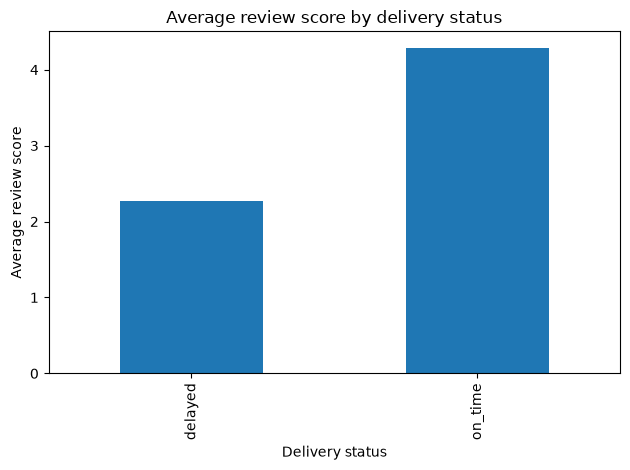

In [ ]:
# [1.3-D] 시각화
#
# 힌트
# - kind = "bar"
# - x = "delivery_status"
# - y = "avg_review_score"

ax = delivery_review_df.plot(
    kind="bar",
    x="delivery_status",
    y="avg_review_score",
    legend=False
)

ax.set_title("Average review score by delivery status")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Average review score")
plt.tight_layout()
plt.show()


### 1.3 해석
1. 정상 배송과 지연 배송의 평균 리뷰 점수는 어떻게 달랐는가? 정상 배송의 별점은 4.290589였고 delay는 2.271823으로 정상배송이 리뷰점수가 더 높았다.

2. `delay_days`와 `is_delayed`를 둘 다 만든 이유는? delay_days는 실제 배송일과 예상 배송일의 차이를 일수로 나타내어 배송이 얼마나 빠르거나 늦었는지 확인하기 위해 만들었고 is_delayed는 지연 여부를 0과 1로 단순화하여 지연배송과 비지연 배송 그룹을 비교하기 위해서임.

3. `order_mart`의 Grain은? 주문단위이다.
4. 이 결과만으로 배송 지연이 리뷰 하락의 **원인**이라고 말할 수 있는가? 관련성이 있다고 볼 수 있다. 하지만 다른 요인도 살펴보는 것이 필요하다고 생각하기에 원인이라고 보긴 어렵다고 생각함.
5. 추가로 확인하고 싶은 변수는? 재구매 여부




---

## 1.4 재구매 고객은 몇 명인가? — 지표 정의 비교

### 정의 A
모든 주문을 구매로 간주

### 정의 B
`delivered` 주문만 성공한 구매로 간주

### 핵심
- 실제 고객 식별자: `customer_unique_id`
- 고객별 주문 순서: `ROW_NUMBER()`
- 직전 주문일: `LAG()`
- 재구매 고객: 주문 2회 이상


In [ ]:
# [1.4-A] 정의 A/B 재구매율 비교
#
# 힌트
# - 두 CTE 모두 customer_unique_id 기준 GROUP BY
# - 정의 B에만 delivered 필터
# - repeat customer는 order_count >= 2

repeat_customer_sql = """
WITH all_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id=c.customer_id
    GROUP BY c.customer_unique_id
),

delivered_orders AS (
    SELECT
        c.customer_unique_id AS customer_unique_id,
        COUNT(*) AS order_count
    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id=c.customer_id
    WHERE o.order_status ='delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    'all_orders' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM all_orders

UNION ALL

SELECT
    'delivered_only' AS definition,
    COUNT(*) AS customer_count,
    SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) AS repeat_customer_count,
    ROUND(
        100.0 * SUM(CASE WHEN order_count >= 2 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS repeat_customer_rate_pct
FROM delivered_orders;
"""

repeat_customer_df = run_sql(repeat_customer_sql)
repeat_customer_df


,definition,customer_count,repeat_customer_count,repeat_customer_rate_pct
0,all_orders,96096,2997.0,3.12
1,delivered_only,93358,2801.0,3.00


In [ ]:
# [1.4-B] ROW_NUMBER + LAG
#
# 두 Window Function 모두:
# PARTITION BY customer_unique_id
# ORDER BY order_purchase_timestamp, order_id
#
# order_id를 두 번째 정렬 기준으로 넣는 이유:
# 같은 timestamp가 있어도 순서를 안정적으로 결정하기 위해서입니다.

customer_history_sql = """
WITH ordered_customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        ROW_NUMBER() OVER (
            PARTITION BY customer_unique_id
            ORDER BY order_purchase_timestamp, order_id
        ) AS order_number,

        LAG(order_purchase_timestamp) OVER (
            PARTITION BY customer_unique_id
            ORDER BY order_purchase_timestamp, order_id
        ) AS previous_order_timestamp

    FROM olist_orders_dataset AS o
    JOIN olist_customers_dataset AS c
      ON o.customer_id=c.customer_id
)

SELECT
    *,
    DATEDIFF(
        order_purchase_timestamp,
        previous_order_timestamp
    ) AS days_since_previous_order

FROM ordered_customer_orders
WHERE previous_order_timestamp IS NOT NULL;
"""

customer_history_df = run_sql(customer_history_sql)
customer_history_df.head()


,customer_unique_id,order_id,order_status,order_purchase_timestamp,order_number,previous_order_timestamp,days_since_previous_order
0,00172711b30d52eea8b313a7f2cced02,c306eca42d32507b970739b5b6a5a33a,canceled,2018-08-13 09:14:07,2,2018-07-28 00:23:49,16
1,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,delivered,2018-01-14 07:36:54,2,2017-07-27 14:13:03,171
2,004b45ec5c64187465168251cd1c9c2f,9392c5e72885ad5aba87e6223ca9838d,delivered,2018-05-26 19:42:48,2,2017-09-01 12:11:23,267
3,0058f300f57d7b93c477a131a59b36c3,81a93b2fa39e104b865b2bc471c16008,delivered,2018-03-22 18:09:41,2,2018-02-19 17:11:34,31
4,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,delivered,2018-06-03 10:12:57,2,2018-05-23 20:14:21,11


In [ ]:
# [1.4-C] 같은 날 발생한 후속 주문 수
#
# 힌트:
# days_since_previous_order == 0 인 행 개수

same_day_repeat_count = (
    customer_history_df['days_since_previous_order'] == 0
).sum()

print("same-day repeat rows:", same_day_repeat_count)


same-day repeat rows: 961


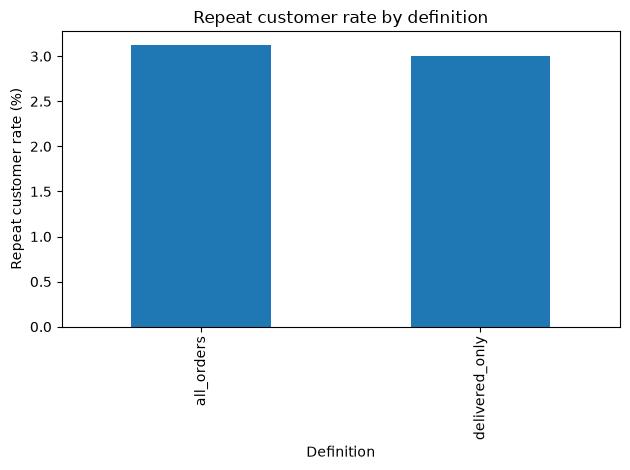

In [ ]:
# [1.4-D] 정의 A/B 재구매율 시각화
#
# 힌트:
# kind = "bar"
# x = "definition"
# y = "repeat_customer_rate_pct"

ax = repeat_customer_df.plot(
    kind="bar",
    x="definition",
    y="repeat_customer_rate_pct",
    legend=False
)

ax.set_title("Repeat customer rate by definition")
ax.set_xlabel("Definition")
ax.set_ylabel("Repeat customer rate (%)")
plt.tight_layout()
plt.show()


### 1.4 해석
1. 왜 `customer_id`가 아니라 `customer_unique_id`를 사용해야 하는가? customer_unique_id를 써야 동일고객을 식별해서 고객별 주문횟수와 재구매 여부를 판단할 수 있음

2. 정의 A/B의 재구매율이 다른 이유는?
B는 delivered 상태의 주문만 포함하기 때문에 취소됐거나 배송 안된 주문 제외되면 달라짐
3. 본인은 어떤 정의가 더 적절하다고 보는가?
정의 A가 적절하다고 생각한다. 재구매는 고객이 실제로 다시 주문했는지를 보는 것으로 배송완료 여부와는 상관없다고 생각하기 때문이다.

4. 같은 날 발생한 후속 주문을 재구매로 볼 것인가?  같은날 발생한 주문은재구매로 보면 안된다고 생각한다. 이는 동일한 과정에서 나뉘었을 가능성이 있기 때문이다. 따라서 첫 주문 이후 일정 시간이 지난 후 발생한 주문만 재구매로 봐야한다고 생각한다.

5. **SQL보다 지표 정의가 먼저**라는 말의 의미는?
SQL은 도구일 뿐이고 무엇을 재구매로 정의할 것인지 처럼 지표를 사람이 먼저 정의하고 결정하고 나서 이후에 SQL로 구현해야 한다는 의미이다.


---

## 1.5 월별 매출 변화 + 카테고리 원인 분해

배송 완료 주문 기준, **2017-01 ~ 2018-08** 분석

### 계산
- 월별 매출
- 전월 매출
- 전월 대비 증감액
- MoM 증감률
- 가장 큰 감소 구간
- 해당 구간의 카테고리별 변화


In [ ]:
# [1.5-A] 월별 매출 + LAG
#
# 힌트
# - month = DATE_FORMAT(order_purchase_timestamp, '%Y-%m')
# - revenue = SUM(oi.price)
# - order_count = COUNT(DISTINCT o.order_id)
# - customer_count = COUNT(DISTINCT c.customer_unique_id)
# - delivered만 사용
# - 기간: '2017-01-01' 이상, '2018-09-01' 미만
# - previous_revenue = LAG(revenue) OVER (ORDER BY month)

monthly_sales_sql = """
WITH monthly_sales AS (
    SELECT
        DATE_FORMAT(
            order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue,
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT c.customer_unique_id) AS customer_count

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id=oi.order_id
    JOIN olist_customers_dataset AS c
      ON o.customer_id=c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
      AND o.order_purchase_timestamp <  '2018-09-01'

    GROUP BY DATE_FORMAT(
        o.order_purchase_timestamp,
        '%Y-%m'
    )
),

monthly_with_previous AS (
    SELECT
        month,
        revenue,
        order_count,
        customer_count,
        LAG(revenue) OVER (
            ORDER BY month
        ) AS previous_revenue
    FROM monthly_sales
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    order_count,
    customer_count,
    ROUND(previous_revenue, 2) AS previous_revenue,

    ROUND(
        revenue - previous_revenue,
        2
    ) AS mom_change,

    ROUND(
        100.0 * (revenue - previous_revenue)
        / NULLIF(previous_revenue, 0),
        2
    ) AS growth_rate_pct

FROM monthly_with_previous
ORDER BY month;
"""

monthly_sales_df = run_sql(monthly_sales_sql)
monthly_sales_df


,month,revenue,order_count,customer_count,previous_revenue,mom_change,growth_rate_pct
0,2017-01,111798.36,750,718,NaN,NaN,NaN
1,2017-02,234223.40,1653,1630,111798.36,122425.04,109.51
2,2017-03,359198.85,2546,2508,234223.40,124975.45,53.36
3,2017-04,340669.68,2303,2274,359198.85,-18529.17,-5.16
4,2017-05,489338.25,3546,3479,340669.68,148668.57,43.64
5,2017-06,421923.37,3135,3076,489338.25,-67414.88,-13.78
6,2017-07,481604.52,3872,3802,421923.37,59681.15,14.15
7,2017-08,554699.70,4193,4114,481604.52,73095.18,15.18
8,2017-09,607399.67,4150,4083,554699.70,52699.97,9.50
9,2017-10,648247.65,4478,4417,607399.67,40847.98,6.73


In [ ]:
# [1.5-B] 가장 큰 감소 월
#
# 힌트:
# growth_rate_pct가 가장 작은 행을 찾습니다.

worst_idx = monthly_sales_df["growth_rate_pct"].idxmin()
worst_month = monthly_sales_df.loc[worst_idx]

print(worst_month)


month                 2017-12
revenue             726033.19
order_count              5513
customer_count           5450
previous_revenue    987765.37
mom_change         -261732.18
growth_rate_pct         -26.5
Name: 11, dtype: object


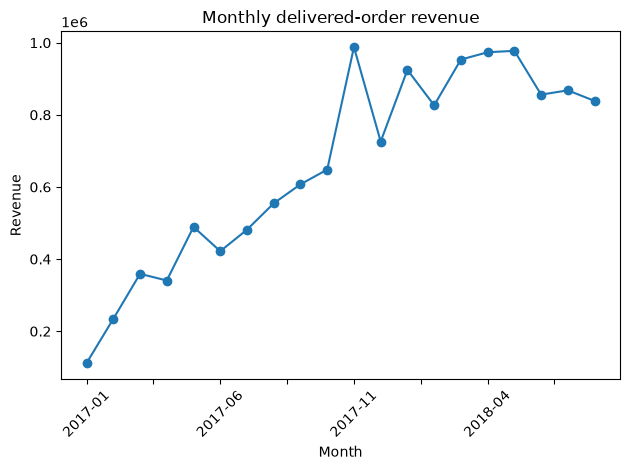

In [ ]:
# [1.5-C] 월별 매출 추이
#
# 힌트:
# kind = "line"
# x = "month"
# y = "revenue"

ax = monthly_sales_df.plot(
    kind="line",
    x="month",
    y="revenue",
    marker="o",
    legend=False
)

ax.set_title("Monthly delivered-order revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# [1.5-D] 2017-11 vs 2017-12 카테고리별 변화
#
# 힌트
# - 카테고리: 번역명이 있으면 영어명, 없으면 원래 카테고리명
# - revenue = SUM(oi.price)
# - delivered만 사용
# - 기간: '2017-11-01' 이상, '2018-01-01' 미만
# - 11월/12월 매출은 conditional aggregation으로 같은 행에 배치
#
# 주의:
# 카테고리별 단순 LAG는 어떤 달의 데이터가 없으면
# '직전 월'이 아닌 '직전에 존재하는 달'을 비교할 수 있습니다.

category_change_sql = """
WITH category_monthly_sales AS (
    SELECT
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ) AS category,

        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        ) AS month,

        SUM(oi.price) AS revenue

    FROM olist_orders_dataset AS o
    JOIN olist_order_items_dataset AS oi
      ON o.order_id=oi.order_id
    JOIN olist_products_dataset AS pr
      ON oi.product_id=pr.product_id
    LEFT JOIN product_category_name_translation AS tr
      ON pr.product_category_name=tr.product_category_name

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-11-01'
      AND o.order_purchase_timestamp <  '2018-01-01'

    GROUP BY
        COALESCE(
            tr.product_category_name_english,
            pr.product_category_name,
            'unknown'
        ),
        DATE_FORMAT(
            o.order_purchase_timestamp,
            '%Y-%m'
        )
),

category_compare AS (
    SELECT
        category,

        SUM(
            CASE
                WHEN month = '2017-11' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_11,

        SUM(
            CASE
                WHEN month = '2017-12' THEN revenue
                ELSE 0
            END
        ) AS revenue_2017_12

    FROM category_monthly_sales
    GROUP BY category
)

SELECT
    category,
    ROUND(revenue_2017_11, 2) AS revenue_2017_11,
    ROUND(revenue_2017_12, 2) AS revenue_2017_12,

    ROUND(
        revenue_2017_12 - revenue_2017_11,
        2
    ) AS change_amount

FROM category_compare
ORDER BY change_amount ASC
LIMIT 10;
"""

category_change_df = run_sql(category_change_sql)
category_change_df


,category,revenue_2017_11,revenue_2017_12,change_amount
0,bed_bath_table,87957.63,50081.16,-37876.47
1,computers_accessories,69676.32,37428.67,-32247.65
2,furniture_decor,62091.27,31073.09,-31018.18
3,watches_gifts,95292.34,69556.92,-25735.42
4,cool_stuff,55696.66,37515.57,-18181.09
5,health_beauty,78274.40,60688.75,-17585.65
6,garden_tools,44275.18,26795.69,-17479.49
7,telephony,26117.63,12780.44,-13337.19
8,office_furniture,17919.20,6684.37,-11234.83
9,agro_industry_and_commerce,13932.49,5291.70,-8640.79


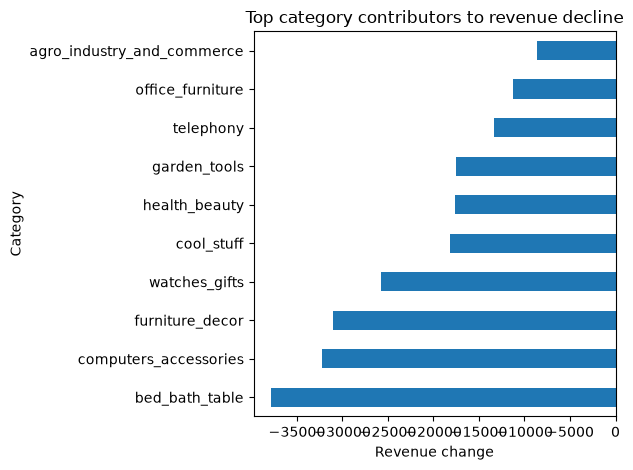

In [ ]:
# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values("change_amount")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


### 1.5 해석
1. 가장 큰 매출 감소 시점은? 2017년 12월
2. 감소 폭은? -26.5
3. 감소에 크게 기여한 카테고리는? bed_bath_table
4. 이 결과만으로 실제 **원인**을 확정할 수 있는가? 없다고 생각한다. 왜냐하면 11월에 일시적으로 매출이 급증했다가 감소한 것이기 때문에 12월에 매출 감소가 유의미한 결과라고 생각하지 않는다.
5. 추가로 필요한 데이터는? 프로모션 여부가 필요하다고 생각한다. 현재 생각을 해보면 11월에 블랙프라이데이가 있어서 일시적으로 매출이 매우 증가했다가 기존의 매출만큼 나온 것 같다고 생각했다.



# 2. 심화 과제 — 아래 중 1개 선택


### A. 배송
배송 지연이 많은 판매자 또는 카테고리 분석

### B. 고객
1회 구매 고객 vs 2회 이상 구매 고객 평균 주문금액 비교

### C. 매출
매출 변화가 큰 시점을 지역 또는 카테고리 관점에서 분해

### D. 자유 분석
상급자에게 보고할 가치가 있는 질문을 직접 정의


In [ ]:
# [심화 과제 공통 Skeleton]
#
# 1) 분석 Grain을 먼저 주석으로 적으세요.
# 2) JOIN Key를 먼저 확인하세요.
# 3) 집계 전/후 행 수 검증 쿼리를 최소 1개 포함하세요.
# 4) 핵심 지표를 2개 이상 만드세요.

# 분석 Grain: 1 row = 1 month
# JOIN Key:
# orders.order_id = order_items.order_id
# orders.customer_id = customers.customer_id

deep_dive_sql = """
WITH base AS (
    SELECT
        -- TODO: 분석에 필요한 key / feature 선택
        DATE_FORMAT(o.order_purchase_timestamp, '%Y-%m') AS month,
        o.order_id,
        c.customer_unique_id,
        oi.price

    FROM olist_orders_dataset AS o

    -- TODO: 필요한 JOIN
    JOIN olist_order_items_dataset AS oi
      ON o.order_id = oi.order_id

    JOIN olist_customers_dataset AS c
      ON o.customer_id = c.customer_id

    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-09-01'
      AND o.order_purchase_timestamp < '2018-01-01'
),

summary AS (
    SELECT
        -- TODO: 분석 Grain에 맞는 지표
        month,
        COUNT(*) AS item_rows,
        COUNT(DISTINCT order_id) AS order_count,
        COUNT(DISTINCT customer_unique_id) AS customer_count,
        ROUND(SUM(price), 2) AS revenue,
        ROUND(
            SUM(price) / COUNT(DISTINCT order_id),
            2
        ) AS avg_order_value

    FROM base
    GROUP BY month
)

SELECT *
FROM summary
ORDER BY month;
"""

# deep_dive_df = run_sql(deep_dive_sql)
# deep_dive_df.head()

In [ ]:
deep_dive_df = run_sql(deep_dive_sql)
deep_dive_df

,month,item_rows,order_count,customer_count,revenue,avg_order_value
0,2017-09,4737,4150,4083,607399.67,146.36
1,2017-10,5214,4478,4417,648247.65,144.76
2,2017-11,8475,7289,7183,987765.37,135.51
3,2017-12,6187,5513,5450,726033.19,131.69


In [ ]:
deep_dive_check_sql = """
SELECT
    COUNT(*) AS item_rows,
    COUNT(DISTINCT o.order_id) AS order_count
FROM olist_orders_dataset AS o
JOIN olist_order_items_dataset AS oi
  ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-09-01'
  AND o.order_purchase_timestamp < '2018-01-01';
"""

deep_dive_check_df = run_sql(deep_dive_check_sql)
deep_dive_check_df

,item_rows,order_count
0,24613,21430


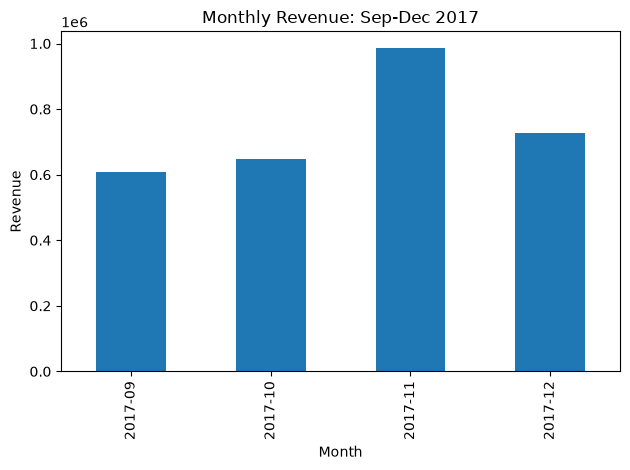

In [ ]:
ax = deep_dive_df.plot(
    x="month",
    y="revenue",
    kind="bar",
    legend=False
)

ax.set_title("Monthly Revenue: Sep-Dec 2017")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.tight_layout()
plt.show()

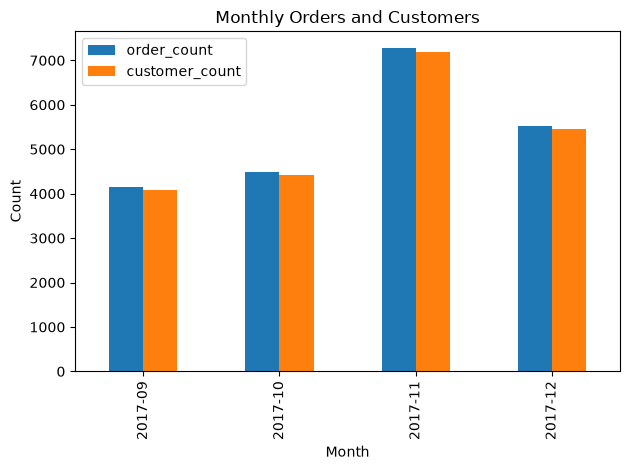

In [ ]:
deep_dive_df.plot(
    x="month",
    y=["order_count", "customer_count"],
    kind="bar"
)

plt.title("Monthly Orders and Customers")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
deep_dive_df[
    ["month", "revenue", "order_count", "customer_count", "avg_order_value"]
]

,month,revenue,order_count,customer_count,avg_order_value
0,2017-09,607399.67,4150,4083,146.36
1,2017-10,648247.65,4478,4417,144.76
2,2017-11,987765.37,7289,7183,135.51
3,2017-12,726033.19,5513,5450,131.69


### 심화 과제 작성
- 분석 질문: 2017년 11월 대비 12월 매출 감소는 어떤 지역과 카테고리에서 크게 나타났는가?
- 분석 Grain: 1 row = 1 month × 1 customer_state × 1 category
- 사용 테이블:olist_orders_dataset, olist_order_items_dataset, olist_customers_dataset, olist_products_dataset, product_category_name_translation
- JOIN Key: orders.order_id = order_items.order_id
orders.customer_id = customers.customer_id
order_items.product_id = products.product_id
products.product_category_name = product_category_name_translation.product_category_name
- 지표 / 파생변수: 월별매출, 주문 수, 고객 수, 11월 대비 12월 매출 변화액, 월 변수
- 필터 기준: order_status = 'delivered', 분석 기간: 2017-11-01 이상 ~ 2018-01-01 미만
- 검증 방법: JOIN 후 COUNT(*)와 COUNT(DISTINCT order_id)를 비교해 주문 하나에 여러 상품 행이 존재함을 확인했다. 또한 지역별 총 매출 변화액을 별도로 집계하여, 지역 × 카테고리 Top 감소 결과와 지역 전체 감소 결과가 일관되는지 확인했다.
- 핵심 숫자 2~3개: SP × bed_bath_table: -13,612.73
SP × furniture_decor: -11,308.83
SP × watches_gifts: -9,407.95
- 해석: 2017년 11월 대비 12월 매출 감소는 특히 SP 지역에서 크게 나타났다. 세부적으로는 bed_bath_table, furniture_decor, watches_gifts, health_beauty, computers_accessories 등 여러 카테고리에서 동시에 감소가 발생했다. 따라서 12월 전체 매출 감소는 특정 하나의 카테고리 문제기보다는 SP 지역의 여러 주요 카테고리에서 매출이 함께 감소한 영향이 큰 것으로 해석할 수 있다. 또 12월 매출 감소가 반드시 12월의 문제라곤 단정할 수 없음. 11월 매출이 플랙프라이데이 등 계절적 요인으로 일시적으로 크게 증가한 후 12월에 정상 수준으로 돌아온 결과일 가능성도 존재함.
- 한계 / 추가 분석: 현재 데이터에는 프로모션 여부나 할인율 재고품절 여부같은 정보가 없어서 매출 감소의 직접적인 원인을 확인할 수 없다. 따라서 프로모션 여부나 할인정보, 재고수준, 판매자수 변화, 일별 주문 추이등을 확인할 필요가 있다.


#### 🤔 회고

Part A에서 겪은 어려움과 해결 과정을 3-5문장으로 적습니다. 끝까지 헷갈린 개념 1-3개도 함께: 지연 일수가 음수로 나와서 의문이 들었는데, 음수로 나오면 일찍 도착한 것이고 양수로 나오면 지연되어서 도착한 것이라는 것을 알았다. repeat customer은 왜 order count>=2인지 궁금했는데 지피티에게 물어보니 그냥 당연하게 재구매라서 두번인것이었다. 왜 상품판매 증가율은 4.48%이고 결제금액 증가율은 28.23%이었는데 왜 결제금액이 더 큰지 의문을 가졌는데 한 주문이 여러 상품행이 존재할 때 동일한 결제 금액이 각 상품행과 결합되어 반복집계 되어서였다. 즉 상품 여러개를 가진 주문이 많아서 하나의 결제금액이 여러 상품행에 반복되는 효과가 더 크게 나타난 것이었다.

Part B(심화 선택)를 진행했다면, 새롭게 알게 된 점을 이어서 적어도 좋습니다: (여기에 답)

#### ⚙️ 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (여기에 답)

- **AI가 이 실험에는 틀린 답을 준 사례**
  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
근데 코드에서 order_grain_sql=""" 이렇게 나오는데 이건 무슨뜻이야?
`orders_grain_sql = """ ... """` 이건 **SQL 문장을 파이썬 문자열로 저장하는 방식**이야.

예를 들면:

```python
orders_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_orders_dataset;
"""
```

여기서

```python
orders_grain_sql
```

은 그냥 **변수 이름**이고,

```python
""" ... """
```

는 여러 줄짜리 문자열을 만들 때 쓰는 **삼중 따옴표**야.

즉 파이썬 입장에서는 저 SQL을 바로 실행하는 게 아니라, 먼저 이런 긴 글자로 저장하는 거야.

```python
orders_grain_sql = "SELECT ... "
```

근데 SQL은 여러 줄로 쓰니까 `"""`를 쓰는 거고.

그다음 아래 코드에서:

```python
orders_grain_df = run_sql(orders_grain_sql)
```

아까 저장해둔 SQL 문자열을 `run_sql()` 함수에 넣어서 **실제로 MySQL에 실행**시키는 거야.

흐름을 보면:

```text
orders_grain_sql = """SQL문"""
        ↓
SQL문을 변수에 저장

run_sql(orders_grain_sql)
        ↓
저 SQL을 DB에서 실행

orders_grain_df
        ↓
결과를 DataFrame으로 저장
```

그래서 `orders_grain_sql`이라는 이름 자체에는 특별한 문법적 의미는 없어. 그냥 작성자가 **“orders의 grain을 확인하는 SQL”**이라는 뜻으로 변수명을 그렇게 붙인 거야.

예를 들어 이름을 이렇게 바꿔도 똑같이 돌아가:

```python
abc = """
SELECT COUNT(*) FROM olist_orders_dataset;
"""

run_sql(abc)
```

다만 `orders_grain_sql`처럼 의미 있는 이름을 쓰는 게 코드를 읽기 편해서 그렇게 쓰는 거야.

# [1.1-C] payments
# 힌트: 한 주문에 결제 행이 여러 개 존재할 수 있습니다.

payments_grain_sql = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_orders
FROM olist_order_payments_dataset;
"""

payments_grain_df = run_sql(payments_grain_sql)
payments_grain_df
 이 코드를 돌렸을때는 total_rows=103886, distinct_orders=99440이었거든 그러면 한 주문에 결제행이 여러개 존재한다는거잖아 근데 한주문에 결제행이 왜 여러개존재하는거야? 결제를 여러번 하ㅡㄴㄴ것도 아닐텐데?

 맞아. **`total_rows=103886`, `distinct_orders=99440`이면 일부 주문은 결제 행이 여러 개 있다는 뜻**이야.

근데 그게 꼭 “같은 주문을 실수로 여러 번 결제했다”는 뜻은 아니야. 이 Olist 결제 데이터에서는 한 주문에 대해 **결제 수단이 나뉘거나, 결제가 여러 분할로 기록될 수 있어서** `order_id`가 여러 행으로 나타날 수 있어.

예를 들어 주문 하나가 이렇게 기록될 수 있어.

```text
order_id   payment_sequential   payment_type   payment_value
A001       1                    credit_card    30000
A001       2                    voucher        5000
```

이 경우 실제 주문은 1개지만, 결제 기록은 2행이야.

또 신용카드 결제라도 데이터 구조상 **결제 시도/분할/복수 수단** 등이 별도 행으로 저장될 수 있어. 그래서 `payments` 테이블의 Grain은 보통

> **1 row = 1 payment record**

로 보는 게 맞고, `1 row = 1 order`가 아니야.

그래서 지금 결과는 이렇게 해석하면 돼.

```text
103,886 payment rows
99,440 distinct orders
```

즉 약 4,446개 정도의 추가 결제 행이 있다는 뜻이고, 일부 주문에서 `order_id`가 반복되고 있다는 뜻이야.

그리고 이게 JOIN에서 중요해. `orders`와 `payments`를 그냥 JOIN하면, 한 주문에 결제행이 2개 있으면 주문 정보도 2번 반복될 수 있어. 그래서 결제금액을 합산할 때는 주문 단위로 먼저 묶는 게 안전할 수 있어.

예를 들면:

```sql
SELECT
    order_id,
    SUM(payment_value) AS total_payment
FROM olist_order_payments_dataset
GROUP BY order_id;
```

이렇게 하면 **여러 결제행을 주문 단위 1행으로 다시 합칠 수 있어.**

한 줄로 정리하면:

> `payments`는 주문 테이블이 아니라 결제 기록 테이블이라서, 하나의 주문이 여러 결제행으로 표현될 수 있다.

근데 이 코드를 돌렸는데
.dataframe tbody tr th:only-of-type {
    vertical-align: middle;
}

.dataframe tbody tr th {
    vertical-align: top;
}

.dataframe thead th {
    text-align: right;
}




  
  joined_rows
  orders_after_join
  wrong_item_amount
  wrong_payment_amount




  0
  115035
  96477
  13813828.71
  19776160.44

  wrong_item_amount랑 wrong_payment_amount랑 엄청 많이 나오는데 이건 왜이런거야?

  응, **그게 바로 이 `naive JOIN` 실습에서 일부러 확인하려는 문제야.**  
지금 코드가 틀려서 에러가 난 게 아니라, **JOIN 때문에 금액이 중복 집계되는 현상을 성공적으로 재현한 것**이야.

네 결과를 보면:

```text
joined_rows       = 115,035
orders_after_join = 96,477
wrong_item_amount = 13,813,828.71
wrong_payment_amount = 19,776,160.44
```

먼저 이것부터 봐.

```text
고유 주문 수       96,477
JOIN 결과 행 수   115,035
```

즉 주문은 96,477개인데 JOIN하고 나니까 **115,035행**으로 늘어났어.

왜냐하면 `orders`에 연결한 두 테이블이 모두 주문 하나에 여러 행을 가질 수 있기 때문이야.

```text
orders
1 주문 = 1행

order_items
1 주문 = 여러 상품 행 가능

payments
1 주문 = 여러 결제 행 가능
```

문제는 `order_items`와 `payments`를 **동시에 JOIN**한 거야.

예를 들어 어떤 주문이 있다고 해보자.

### 주문 A

상품은 2개:

```text
order_items

order_id   item    price
A          상품1    10,000
A          상품2    20,000
```

실제 상품 총액은:

```text
30,000
```

결제 기록도 2개:

```text
payments

order_id   payment
A          15,000
A          15,000
```

실제 결제 총액도:

```text
30,000
```

그런데 둘을 동시에 JOIN하면 이렇게 돼.

```text
item       price      payment
상품1      10,000     15,000
상품1      10,000     15,000
상품2      20,000     15,000
상품2      20,000     15,000
```

왜 4줄이냐면:

```text
상품 2개 × 결제 2개 = 4개 조합
```

이 생겼기 때문이야.

그 상태에서 네 코드가:

```sql
SUM(oi.price)
```

하면:

```text
10,000 + 10,000 + 20,000 + 20,000
= 60,000
```

실제 상품금액은 **30,000원인데 60,000원으로 두 배**가 됐지.

결제금액도:

```sql
SUM(p.payment_value)
```

하면:

```text
15,000 + 15,000 + 15,000 + 15,000
= 60,000
```

원래 결제금액은 30,000인데 이것도 두 배.

이게 바로 **Row Explosion**이야.

세션에서도 JOIN 후 Grain이 `1 order`에서 더 작은 단위로 바뀌면서 같은 measure가 반복될 수 있다고 설명했어.

그래서 아까 `correct_metric_sql`에서는 일부러 이렇게 따로 계산했던 거야.

```text
주문 수
orders만 사용

상품 판매금액
orders + order_items

결제금액
orders + payments
```

반면 지금 naive JOIN은:

```text
orders
   ↓
order_items
   ↓
payments
```

를 한 번에 연결해서 **상품 행 × 결제 행 조합이 만들어진 것**이고.

그리고 `wrong_item_amount`나 `wrong_payment_amount`가 1천만 단위인 것 자체가 무조건 이상하다는 뜻은 아니야. 데이터 전체 금액의 합이니까 원래도 큰 값이 나올 수 있어. **진짜 확인해야 하는 건 아까 `correct_df`의 금액보다 얼마나 커졌느냐**야.

예를 들어:

```text
correct_item_amount = 13,000,000
wrong_item_amount   = 13,813,828
```

처럼 나오면 JOIN으로 약 81만 정도가 중복 집계된 거지.

네가 아까 돌린 **`correct_df` 결과 3개 숫자**도 보내주면, 내가 `naive JOIN` 때문에 **주문 수 / 상품금액 / 결제금액이 각각 얼마나 부풀려졌는지** 정확히 비교해서 설명해줄게.

근데 왜 금액 부풀림 비율이 결제금액이 더 클까
응. 결제금액 쪽 부풀림 비율이 더 클 수 있는 이유는, JOIN할 때 결제행이 상품행 수만큼 반복되는 효과가 더 크게 나타났기 때문이야.
예를 들어 어떤 주문이:
상품 3개
결제행 1개
라고 해보자.
원래는:
상품금액: 10 + 20 + 30 = 60
결제금액: 60
그런데 order_items와 payments를 같이 JOIN하면:
상품1 - 결제60
상품2 - 결제60
상품3 - 결제60
이렇게 돼.
그러면 상품금액은 여전히:
10 + 20 + 30 = 60
인데 결제금액은:
60 + 60 + 60 = 180
으로 3배가 돼.
반대로 어떤 주문이:
상품 1개
결제행 3개
라면 이번에는 상품금액이 3번 반복되고, 결제금액은 각 결제행이 한 번씩만 나타날 수 있어.
즉 실제 데이터 전체에서는 주문마다:
상품행 개수
결제행 개수
가 다르기 때문에, 어느 쪽이 더 부풀지는 **각 주문의 multiplicity(반복 횟수)**에 따라 달라져.
네 데이터에서는 결과적으로 상품 여러 개를 가진 주문이 많아서, 하나의 결제금액이 여러 상품행에 반복되는 효과가 더 크게 나타난 것으로 볼 수 있어.

아니 근데 재구매율이 막대그래프가 별반 차이없어보이는데 이게맞나

응, **맞을 가능성이 높아.** 그래프만 보면 `all_orders`가 약 **3.1%**, `delivered_only`가 약 **3.0%** 정도라서 차이가 아주 작아 보여.

이게 이상한 게 아니라, 오히려 **“재구매율 정의를 전체 주문으로 잡든 배송완료 주문만 잡든 결과가 크게 달라지지 않았다”**는 해석이 가능해.

중요한 건 막대 높이가 비슷하다고 해서 코드가 잘못된 게 아니라는 거야. 실제 숫자를 확인하려면:

```python
repeat_customer_df
```

를 출력해서 `repeat_customer_rate_pct` 값을 직접 보면 돼.

예를 들어 결과가:

```text
definition       repeat_customer_rate_pct
all_orders       3.12
delivered_only   3.00
```

이라면 차이는 겨우 **0.12%p**야.

그래서 과제 해석은 이런 식으로 할 수 있어:

> 전체 주문을 기준으로 한 재구매율과 배송 완료 주문만을 기준으로 한 재구매율은 큰 차이를 보이지 않았다. 따라서 이 데이터에서는 주문 상태 필터 적용 여부가 재구매 고객 비율에 미치는 영향이 크지 않은 것으로 나타났다.

다만 표현을 정확히 하자면 **“0.12% 차이”가 아니라 “0.12%p(퍼센트포인트) 차이”**라고 하는 게 좋아.

그리고 이 결과가 꽤 낮아 보이는 이유도 있어. 지금 재구매 고객의 정의가:

```sql
order_count >= 2
```

즉 **같은 `customer_unique_id`가 데이터 기간 동안 주문을 두 번 이상 한 경우**만 재구매로 세는 방식이라, 한 번만 구매한 고객이 많으면 3% 정도로 낮게 나오는 게 충분히 가능해.

그래서 지금 그래프가 비슷한 건 **정상일 수 있어.**  
`repeat_customer_df`의 실제 숫자 2행을 보내주면 내가 차이가 정확히 몇 %p인지까지 같이 해석해줄게.
```

근데 왜 월별매출이랑 더해서 LAG를 쓰는거야
왜냐하면 **월별 매출만 계산하면 “각 달 매출이 얼마인지”까지만 알 수 있고, LAG를 쓰면 “전월보다 얼마나 늘었거나 줄었는지”까지 볼 수 있기 때문**이야.

예를 들어 월별 매출이 이렇게 있다고 해보자.

```text
month     revenue
2017-01   100
2017-02   130
2017-03   120
```

여기서 그냥 `revenue`만 보면 각 달 매출은 알 수 있어.

근데:

```sql
LAG(revenue) OVER (ORDER BY month)
```

를 쓰면 이전 달 매출을 옆에 붙일 수 있어.

```text
month     revenue   previous_revenue
2017-01   100       NULL
2017-02   130       100
2017-03   120       130
```

그래서:

```sql
revenue - previous_revenue
```

를 하면

```text
2017-02 → +30
2017-03 → -10
```

처럼 **전월 대비 증감액**을 구할 수 있고,

```sql
100 * (revenue - previous_revenue) / previous_revenue
```

를 하면 **전월 대비 성장률**도 구할 수 있어.

즉 정리하면:

> 월별 매출 집계 = 각 달의 매출 수준 확인  
> `LAG` = 바로 이전 달 매출 가져오기  
> 둘을 같이 사용 = 월별 매출 추이와 전월 대비 변화를 함께 분석

세션 자료도 `LAG`를 전월 대비 매출 증감 분석에 사용하는 예시로 설명하고 있어.

그래서 이 문제는 단순히 월별 매출을 구하는 문제가 아니라, **“이번 달이 지난달보다 얼마나 성장했는가?”**까지 보려는 거야.

`barh`는 **horizontal bar chart**, 즉 **가로 막대그래프**야.

예를 들어 pandas에서:

```python
df.plot(kind="barh")
```

라고 하면 막대가 왼쪽→오른쪽으로 뻗는 형태로 나와.

반대로:

```python
df.plot(kind="bar")
```

는 세로 막대그래프야.

그래서 카테고리 이름처럼 글자가 길 때는 `barh`가 보기 더 편해. 예를 들어:

```python
category_change_df.plot(
    x="category",
    y="change_amount",
    kind="barh"
)
```

이렇게 하면 카테고리 이름이 y축에 길게 표시되고, 매출 증감액이 가로 막대로 보여.

한 줄로:

> `bar` = 세로 막대  
> `barh` = 가로 막대(horizontal)

# [1.5-E] 감소 기여 Top 10 그래프
#
# 힌트:
# kind = "barh"
# x = "category"
# y = "change_amount"

plot_df = category_change_df.sort_values("barh")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()
이거 돌렸는데  ---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
Cell In[113], line 8
      4 # kind = "barh"
      5 # x = "category"
      6 # y = "change_amount"
      7
----> 8 plot_df = category_change_df.sort_values("barh")
      9
     10 ax = plot_df.plot(
     11     kind="bar",

File ~/colab-local-env/lib/python3.14/site-packages/pandas/core/frame.py:8361, in DataFrame.sort_values(self, by, axis, ascending, inplace, kind, na_position, ignore_index, key)
   8357             )
   8358         elif by:
   8359             # len(by) == 1
   8360
-> 8361             k = self._get_label_or_level_values(by[0], axis=axis)
   8362
   8363             # need to rewrap column in Series to apply key function
   8364             if key is not None:

File ~/colab-local-env/lib/python3.14/site-packages/pandas/core/generic.py:1764, in NDFrame._get_label_or_level_values(self, key, axis)
   1760             values = self.xs(key, axis=first_other_axes)._values
   1761         elif self._is_level_reference(key, axis=axis):
   1762             values = self.axes[axis].get_level_values(key)._values
   1763         else:
-> 1764             raise KeyError(key)
   1765
   1766         # Check for duplicates
   1767         if values.ndim > 1:

KeyError: 'barh' 이렇게 에러가 떠 맞지않아? 왜 에러가 뜨는거ㅣ
응, 에러 나는 게 맞아. 이유는 **`sort_values("barh")`에서 `"barh"`를 컬럼명으로 착각해서** 그래.

`barh`는 **그래프 종류**고, 정렬 기준 컬럼이 아니야.

지금 `category_change_df`에는 아마 이런 컬럼들이 있지:

```text
category
revenue_2017_11
revenue_2017_12
change_amount
```

그래서 정렬은 `change_amount` 기준으로 해야 해.

```python
plot_df = category_change_df.sort_values("change_amount")

ax = plot_df.plot(
    kind="barh",
    x="category",
    y="change_amount",
    legend=False
)

ax.set_title("Top category contributors to revenue decline")
ax.set_xlabel("Revenue change")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()
```

즉 차이는 이거야:

```python
sort_values("change_amount")
```

→ **어떤 값 기준으로 정렬할지**

```python
kind="barh"
```

→ **어떤 모양의 그래프로 그릴지**

네가 쓴

```python
sort_values("barh")
```

는 pandas한테  
> `"barh"`라는 컬럼을 찾아서 정렬해줘

라고 한 셈인데, 그런 컬럼이 없으니까:

```text
KeyError: 'barh'
```

가 난 거야.

그리고 감소 기여 Top 10이면 `change_amount`가 음수인 값들이고, 이미 SQL에서:

```sql
ORDER BY change_amount ASC
LIMIT 10
```

으로 가장 많이 감소한 10개를 가져왔으니까, 사실 정렬을 다시 안 해도 돼. 그래도 그래프 표시 순서를 예쁘게 하려면:

```python
sort_values("change_amount")
```

를 쓰면 돼.

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은 무엇이었나요? 11월에 블랙프라이데이의 영향으로 매출이 일시적으로 증가했을 가능성이 있다는 판단